In [1]:
# %% =========================================================
# IMPORTS
# =========================================================
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import seaborn as sns
sns.set_theme()

In [2]:
# %% =========================================================
# CONFIG
# =========================================================
STATE = "13"
COUNTIES = ["121", "089", "067", "135"]
RANDOM_STATE = 42
N_CLUSTERS = 5

In [3]:
# %% =========================================================
# LOAD DATA
# =========================================================
X_df = pd.read_parquet(
    "../data/processed_predictors/atlanta_2023_predictor_dataset.parquet"
)

y_df = pd.read_parquet(
    "../data/processed_job_accessibility/accessibility_state-GA_counties-121-089-067-135_year-2023_thresholds-15-30-45-60.parquet"
)

In [4]:
# %% =========================================================
# TARGET CONSTRUCTION
# =========================================================
y_df = y_df.sort_values("from_id").reset_index(drop=True)

weights = np.array([1.0, 0.7, 0.4, 0.2])

band_0_15 = y_df["jobs_15min"].clip(lower=0)
band_15_30 = (y_df["jobs_30min"] - y_df["jobs_15min"]).clip(lower=0)
band_30_45 = (y_df["jobs_45min"] - y_df["jobs_30min"]).clip(lower=0)
band_45_60 = (y_df["jobs_60min"] - y_df["jobs_45min"]).clip(lower=0)

weighted_sum = (
      weights[0] * band_0_15
    + weights[1] * band_15_30
    + weights[2] * band_30_45
    + weights[3] * band_45_60
)

y_df["access_index"] = np.log1p(weighted_sum)

In [5]:
# %% =========================================================
# MERGE FEATURES + TARGET
# =========================================================
df = X_df.merge(
    y_df[["from_id", "access_index"]],
    left_on="tract_id",
    right_on="from_id",
    how="inner"
)

In [6]:
# %% =========================================================
# LOAD GEOMETRY
# =========================================================
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)
tracts = tracts[tracts["COUNTYFP"].isin(COUNTIES)].copy()
tracts["tract_id"] = tracts["GEOID"].astype(str)

df = df.merge(
    tracts[["tract_id", "geometry"]],
    on="tract_id",
    how="left"
)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts.crs)

In [7]:
# %% =========================================================
# PROJECT TO METRIC CRS
# =========================================================
gdf = gdf.to_crs(epsg=5070).copy()

In [8]:
# %% =========================================================
# FEATURE PREPARATION
# =========================================================
gdf["centroid"] = gdf.geometry.centroid
gdf["x"] = gdf.centroid.x
gdf["y"] = gdf.centroid.y

drop_cols = [
    "tract_id",
    "from_id",
    "geometry",
    "centroid",
    "x",
    "y",
    "cluster",
    "access_index"
]

feature_cols = [c for c in gdf.columns if c not in drop_cols]

X = gdf[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = gdf["access_index"]

# optional scaling (important for linear regression)
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# %% =========================================================
# SPATIAL CLUSTERING (CV FOLDS)
# =========================================================
coords = np.column_stack([gdf["x"], gdf["y"]])

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init="auto"
)

gdf["cluster"] = kmeans.fit_predict(coords)

In [9]:
# %% =========================================================
# SPATIAL CROSS-VALIDATED LINEAR REGRESSION
# =========================================================
results = []
all_predictions = []

for test_cluster in range(N_CLUSTERS):

    print("\n" + "=" * 60)
    print(f"TEST CLUSTER: {test_cluster}")
    print("=" * 60)

    train_mask = gdf["cluster"] != test_cluster
    test_mask = gdf["cluster"] == test_cluster

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")

    results.append({
        "cluster": test_cluster,
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    })

    fold_preds = pd.DataFrame({
        "tract_id": gdf.loc[test_mask, "tract_id"].values,
        "cluster": test_cluster,
        "actual": y_test.values,
        "predicted": y_pred
    })

    all_predictions.append(fold_preds)


TEST CLUSTER: 0
MAE:  0.6556
RMSE: 0.8457
R2:   0.4348

TEST CLUSTER: 1
MAE:  0.7581
RMSE: 1.1531
R2:   0.4065

TEST CLUSTER: 2
MAE:  0.6188
RMSE: 0.7771
R2:   0.6550

TEST CLUSTER: 3
MAE:  0.5457
RMSE: 0.7192
R2:   0.6172

TEST CLUSTER: 4
MAE:  0.7710
RMSE: 0.9160
R2:   0.1510


In [10]:
# %% =========================================================
# RESULTS
# =========================================================
predictions_df = pd.concat(all_predictions, ignore_index=True)
results_df = pd.DataFrame(results)

print(results_df)
print("\nMean performance:")
print(results_df[["mae", "rmse", "r2"]].mean())

   cluster       mae      rmse        r2
0        0  0.655646  0.845718  0.434777
1        1  0.758068  1.153104  0.406487
2        2  0.618764  0.777101  0.655041
3        3  0.545737  0.719224  0.617208
4        4  0.770988  0.915997  0.150963

Mean performance:
mae     0.669840
rmse    0.882229
r2      0.452895
dtype: float64


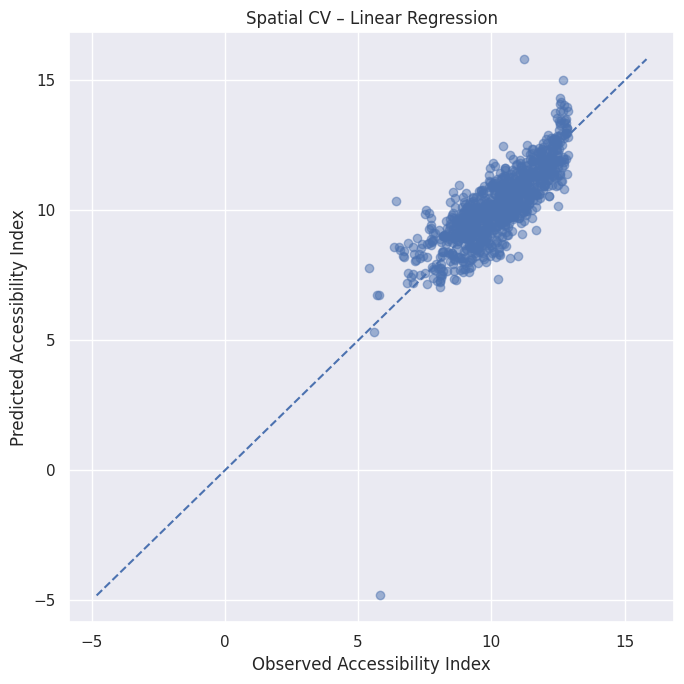

In [11]:
# %% =========================================================
# SCATTER PLOT
# =========================================================
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    predictions_df["actual"],
    predictions_df["predicted"],
    alpha=0.5
)

min_val = min(predictions_df["actual"].min(), predictions_df["predicted"].min())
max_val = max(predictions_df["actual"].max(), predictions_df["predicted"].max())

ax.plot([min_val, max_val], [min_val, max_val], "--")

ax.set_xlabel("Observed Accessibility Index")
ax.set_ylabel("Predicted Accessibility Index")
ax.set_title("Spatial CV – Linear Regression")

plt.tight_layout()
plt.show()

In [12]:
# %% =========================================================
# COEFFICIENT IMPORTANCE
# =========================================================
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print(coef_df.head(20))

                            feature   coefficient
3                         pct_18_64  98379.883861
2                      pct_under_18  80046.269826
4                       pct_over_65  69003.391057
29           occupied_housing_units      1.380317
30             vacant_housing_units      1.117312
43             intersection_density      0.235791
45                   street_density      0.222420
10                per_capita_income      0.219572
20       pct_one_vehicle_households      0.207643
17             pct_bachelors_degree      0.146118
19        pct_no_vehicle_households      0.136983
1                population_density      0.126037
46                 restaurant_count      0.109888
58                       park_count      0.107911
23       pct_public_transit_commute      0.105983
9           median_household_income      0.102169
11                     poverty_rate      0.089176
8                        households      0.082747
21  pct_two_plus_vehicle_households      0.076259


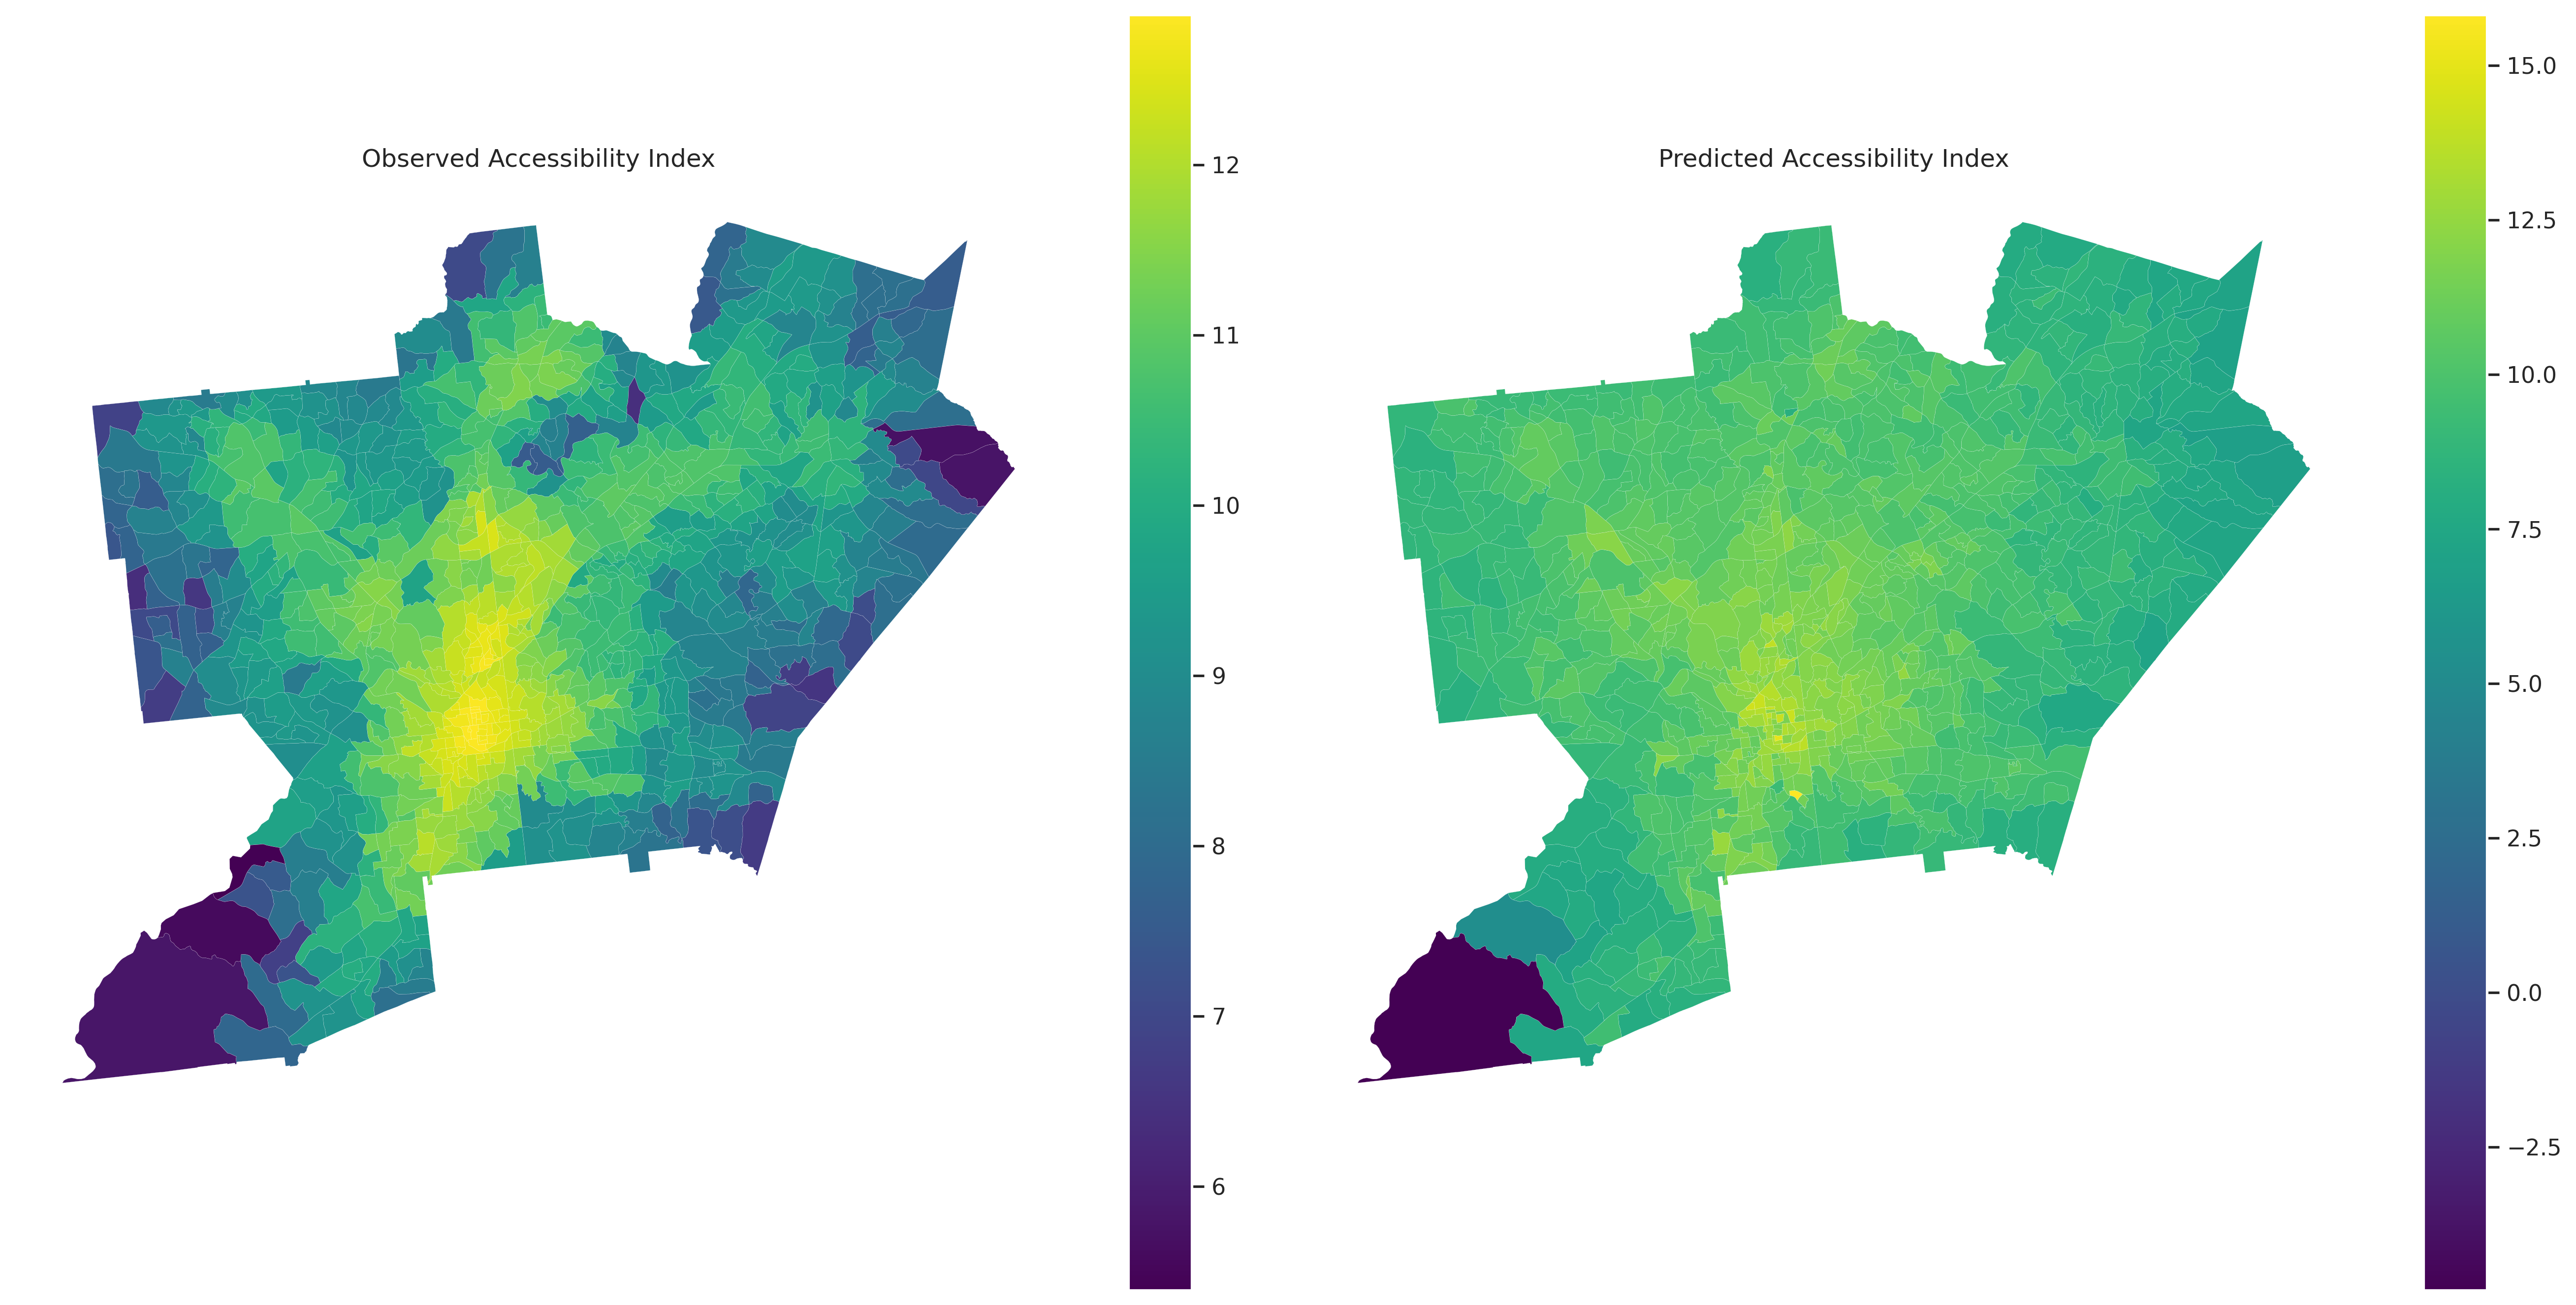

In [13]:
# %% =========================================================
# MAP VISUALIZATION
# =========================================================
map_gdf = gdf[["tract_id", "geometry"]].merge(
    predictions_df[["tract_id", "actual", "predicted"]],
    on="tract_id",
    how="inner"
)

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=gdf.crs)
map_gdf = map_gdf.to_crs(epsg=5070)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), dpi=300)

plot_kws = dict(
    cmap="viridis",
    legend=True,
    linewidth=0.05,
    edgecolor="white",
    missing_kwds={"color": "lightgrey"}
)

map_gdf.plot(column="actual", ax=axes[0], **plot_kws)
axes[0].set_title("Observed Accessibility Index")
axes[0].axis("off")

map_gdf.plot(column="predicted", ax=axes[1], **plot_kws)
axes[1].set_title("Predicted Accessibility Index")
axes[1].axis("off")

plt.tight_layout()
plt.show()